#  NSR vs. PLATO passband

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import sys
import h5py
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from zipfile import ZipFile

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

import warnings 
warnings.filterwarnings("ignore")

## Data Analysis: Indiviual N-CAM LCs

In [3]:
# User parameters
numStar = 2
idir  = "/lhome/nicholas/data/paperNSR"
ofile = idir + "/results.ftr"

### Test example

In [4]:
istar = f"{idir}/000000001"
phot = LightCurve(istar, mode="multi")
phot.unpack()

In [5]:
filenames = phot.files("hdf5")
filenames

['/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/paperNSR/000000001/000000001_Ncam2.6_Q1.hdf5']

In [12]:
lc = LightCurve(filenames[0], mode='single')
lc.data().head()

[Warning]: getTime(): Time array not present in StarPositions group!


,flux
0,222468.724243
1,221964.041382
2,222818.238770
3,222221.818359
4,222222.646973


In [7]:
lc.obs()

(1, 1, 1)

In [ ]:
df = 

In [9]:
lc.getRMS()

102.62460990765973

In [10]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(9,4.5));
# fig.savefig('camera_JitterNone_Star1.png', bbox_inches='tight', dpi=200)

KeyError: 'time'

### No jitter

In [ ]:
# phot = LightCurve(inputDirNone, mode="multi")
# phot.analyse_single_camera(inputDirNone, outputFileNone, numStar)

In [ ]:
# Load results and sort logically
df1 = pd.read_feather(outputFileNone)
df1 = df1.loc[df1["flag"] == 0]
df1_tar = df1.loc[df1["ncon"] == 0]
df1_con = df1.loc[df1["ncon"] > 0]
df1_c = df1.loc[(df1["ncon"] > 0) & (df1["rcon"] < 2)]
df1

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_c, column="dmag", figsize=(8,6))
ax.set_title("No Jitter: Individual N-CAM");

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

fig.savefig('camera_JitterNone_con_dmag.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_c, column="rcon", figsize=(8,6))
ax.set_title("No Jitter: Individual N-CAM");

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

fig.savefig('camera_JitterNone_con_dpix.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_tar, column="rOA")
ax.set_title("No Jitter: Individual N-CAM and no stellar contaminants");

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_tar, column="quarter")
ax.set_title("No Jitter: Individual N-CAM and no stellar contaminants");

### Red Noise

In [ ]:
# phot = LightCurve(inputDirRed, mode="multi")
# phot.analyse_single_camera(inputDirRed, outputFileRed, numStar)

In [ ]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRed)
df2 = df2.loc[df2["flag"] == 0]
df2_tar = df2.loc[df2["ncon"] == 0]
df2_con = df2.loc[df2["ncon"] > 0]
df2_c = df2.loc[(df2["ncon"] > 0) & (df2["rcon"] < 2)]
df2.head()

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2_c, column="dmag")
ax.set_title("Red Noise: Individual N-CAM");

### Prime Jitter

In [ ]:
# phot = LightCurve(inputDirPrime, mode="multi")
# phot.analyse_single_camera(inputDirPrime, outputFilePrime, numStar)

In [ ]:
# Load results and sort logically
df3 = pd.read_feather(outputFilePrime)
df3 = df3.loc[df3["flag"] == 0]
df3_tar = df3.loc[df3["ncon"] == 0]
df3_con = df3.loc[df3["ncon"] > 0]
df3_c = df3.loc[(df3["ncon"] > 0) & (df3["rcon"] < 2)]
df3.head()

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df3_c, column="SPR")
ax.set_title("Prime Jitter: Individual N-CAM");

### Remove outliers

In [ ]:
# Remove outlier from data 
SPR_lim = 0.1
df1_outlier = df1.loc[(df1["ncon"] > 0) & (df1["SPR"] > SPR_lim)]
df2_outlier = df2.loc[(df2["ncon"] > 0) & (df2["SPR"] > SPR_lim)]
df3_outlier = df3.loc[(df3["ncon"] > 0) & (df3["SPR"] > SPR_lim)]
df1_inlier = df1.drop(df1_outlier["index"])
df2_inlier = df2.drop(df2_outlier["index"])
df3_inlier = df3.drop(df3_outlier["index"])

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1_inlier, column="ncon")
ax.set_title("Prime Jitter: Individual N-CAM");

In [ ]:
# Find n worst outliers
n = 10
df1_outlier["NSR"].argsort()[-n:][::-1]

In [ ]:
df1_outlier.iloc[4234]

### Residuals

In [ ]:
# Residuals for all stars
df21 = df1.copy()
df31 = df2.copy()
df23 = df3.copy()
df21["res"] = df2["NSR"] - df1["NSR"]
df31["res"] = df3["NSR"] - df1["NSR"]
df23["res"] = df2["NSR"] - df3["NSR"]

# Residuals for single stars
df21_tar = df1_tar.copy()
df31_tar = df2_tar.copy()
df23_tar = df3_tar.copy()
df21_tar["res"] = df2_tar["NSR"] - df1_tar["NSR"]
df31_tar["res"] = df3_tar["NSR"] - df1_tar["NSR"]
df23_tar["res"] = df2_tar["NSR"] - df3_tar["NSR"]

# Residual for inliers
df21_inlier = df1_inlier.copy()
df31_inlier = df2_inlier.copy()
df23_inlier = df3_inlier.copy()
df21_inlier["res"] = df2_inlier["NSR"] - df1_inlier["NSR"]
df31_inlier["res"] = df3_inlier["NSR"] - df1_inlier["NSR"]
df23_inlier["res"] = df2_inlier["NSR"] - df3_inlier["NSR"]

### Residuals for all

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df21_tar, column="ferr", residuals="camera", figsize=(8,6))
ax.set_title(r"Residuals $|\rm {NSR}_{red} - {NSR}_{none}|$", pad=10);
fig.savefig('camera_Residuals_Red-None_inlier.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="ferr", residuals="camera", figsize=(8,6))
ax.set_title(r"Residuals $|\rm {NSR}_{prime} - {NSR}_{none}|$", pad=10);
fig.savefig('camera_Residuals_Prime-None_inlier.png', bbox_inches='tight', dpi=200)

In [ ]:
# Plot residuals
fig, ax = pt.plotNSRvsMagnitude(df23_tar, column="ferr", residuals="camera")
ax.set_title(r"Residuals $|\rm {NSR}_{prime} - {NSR}_{red}|$", pad=10);

### Residuals for Inliers

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df21_tar, column="ferr", residuals="camera", yscale="linear")
ax.set_title(r"Residuals $(\rm {NSR}_{red} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="ferr", residuals="camera", yscale="linear")
ax.set_title(r"Inliers $(\rm {NSR}_{prime} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df31_tar, column="quarter", residuals="camera", yscale="log")
ax.set_title(r"Inliers $(\rm {NSR}_{prime} - {NSR}_{none})$", pad=10);

In [ ]:
fig, ax = pt.plotNSRvsMagnitude(df23_tar, column="rOA", residuals="camera", yscale="linear")
ax.set_title(r"Residuals $(\rm {NSR}_{red} - {NSR}_{prime})$", pad=10);
fig.savefig('camera_Residuals_Red-Prime_inlier.png', bbox_inches='tight', dpi=200)

---

## 3 - Data Analysis: Merged N-CAM LCs

---

In [272]:
# User parameters
numStar = 400
simDir = "/lhome/nicholas/sims_kul21"
inputDirNone  = simDir + "/jitterNone"
inputDirRed   = simDir + "/jitterRed"
inputDirPrime = simDir + "/jitterPrime"
outputFileNoneMerged  = os.getcwd() + "/resultsJitterNoneMerged.ftr"
outputFileRedMerged   = os.getcwd() + "/resultsJitterRedMerged.ftr"
outputFilePrimeMerged = os.getcwd() + "/resultsJitterPrimeMerged.ftr"

### Test example

<IPython.core.display.Javascript object>


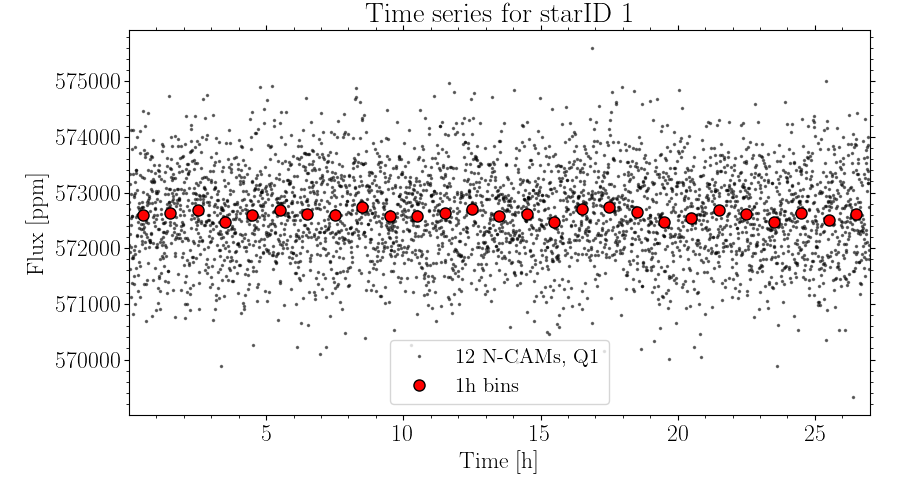

In [276]:
phot = LightCurve(inputDirNone+"/000000001/", mode="multi")
phot.unpack()

lc.getNSR(influx="ppm")

fig, ax = lc.plot(time_unit="h", binsize=1, cameras=12, quarter=1)
ax.set_title("Time series for starID 1");
fig.savefig('camera_TimeSeries_star1.png', bbox_inches='tight', dpi=200)

phot.remove()

---
### Red Noise
---

In [293]:
# phot = LightCurve(inputDirRed, mode="multi")
# phot.merge_cameras(outputFileRedMerged, numStar)

In [294]:
# Load results and sort logically
df2 = pd.read_feather(outputFileRedMerged)
df2_tar = df2.loc[df2["ncon"] == 0]
df2.head()

,index,star,mag,rOA,quarter,ncam,ncon,SPR,NSR,flux_err,flag
0,0,1,9.64,12.928117,1,17,1,0.156194,27.512461,515.450500,0.0
1,1,1,9.64,12.928117,2,6,1,0.156194,47.168289,518.454773,0.0
2,2,1,9.64,12.928117,3,18,1,0.156194,27.068834,515.822021,0.0
3,3,1,9.64,12.928117,4,6,1,0.156194,46.532719,516.264893,0.0
4,4,1,9.64,12.928117,5,18,1,0.156194,26.841160,517.940857,0.0


<IPython.core.display.Javascript object>


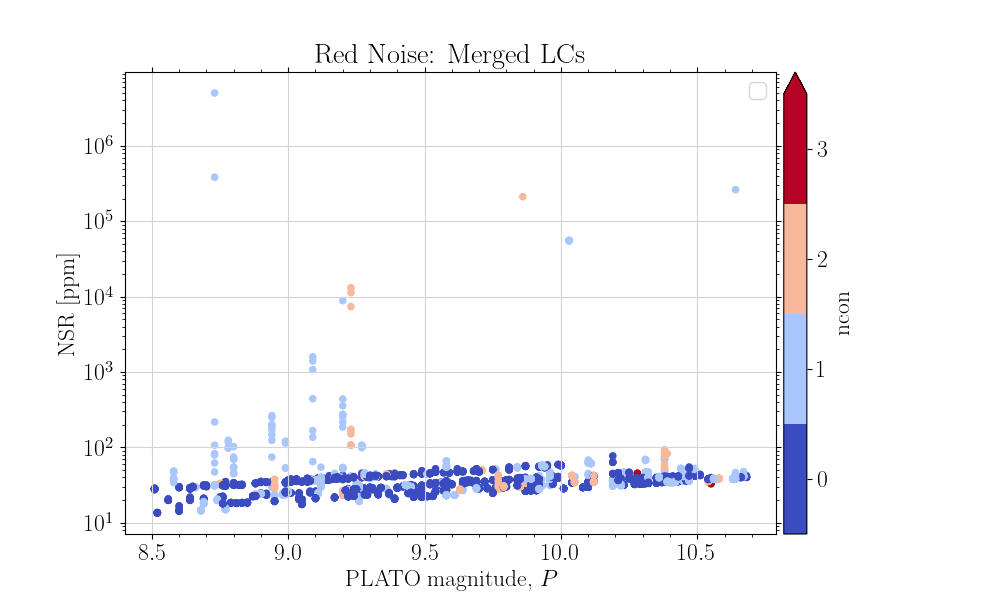

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [295]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2, column="ncon")
ax.set_title("Red Noise: Merged LCs");

<IPython.core.display.Javascript object>


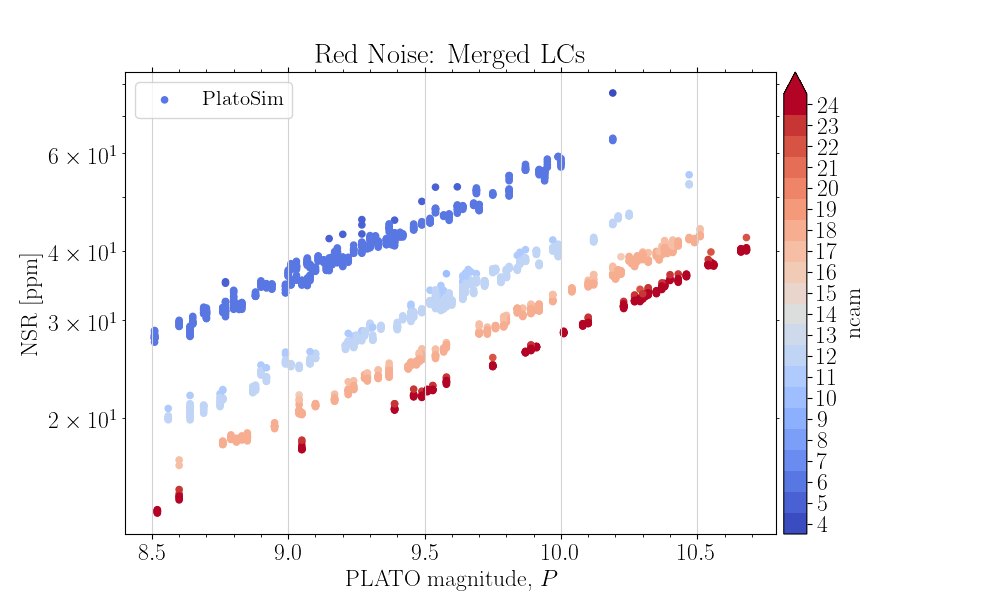

In [297]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df2_nocon, column="ncam")
ax.set_title("Red Noise: Merged LCs");